# Annual 最終模型的空間診斷

只比較兩個模型：

1. **No predictors**：截距加空間 GP，不加入外部 predictor。
2. **Final selected predictors**：目前 spatial FFS 選出的 predictors 與 kernel。

兩者使用相同的 1,385 個臺灣本島 GRID、5 個 folds、target-specific buffer 與 training cap；不包含 elevation-only。

In [15]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed

cwd = Path.cwd().resolve()
if (cwd / 'src' / 'spatial_predictor_selection.py').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'src' / 'spatial_predictor_selection.py').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError('請從 repository 根目錄或 notebooks/ 執行。')

SRC_DIRECTORY = PROJECT_ROOT / 'src'
if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))

from spatial_diagnostics import (
    plot_isotropy_stationarity_diagnostics,
    prepare_selected_oof_residuals,
)
from spatial_predictor_selection import (
    RANDOM_STATE,
    _fold_contexts,
    evaluate_predictor_set,
    load_predictor_selection_data,
)

TABLE_DIR = PROJECT_ROOT / 'results' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FINAL_OOF_PATH = TABLE_DIR / 'spatial_ffs_selected_oof_predictions.csv'
SELECTION_PATH = TABLE_DIR / 'spatial_ffs_selection_path.csv'
NO_PREDICTOR_OOF_PATH = TABLE_DIR / 'annual_no_predictors_oof_predictions.csv'
COMPARISON_PATH = TABLE_DIR / 'annual_no_predictors_vs_final_oof_predictions.csv'

N_JOBS = -2
REFIT_NO_PREDICTORS = False
TARGETS = ('mu', 'log_sigma', 'xi')
STAGES = ('No predictors', 'Final selected predictors')

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 220,
    'axes.grid': True, 'grid.alpha': 0.22,
})
display({
    'final OOF': FINAL_OOF_PATH,
    'no-predictor cache': NO_PREDICTOR_OOF_PATH,
    'n_jobs': N_JOBS,
    'force refit': REFIT_NO_PREDICTORS,
})

{'final OOF': WindowsPath('C:/Users/User.DESKTOP-4RV84M1/Desktop/論文/fast parameter estimate/fast_parameter_using_NN/results/tables/spatial_ffs_selected_oof_predictions.csv'),
 'no-predictor cache': WindowsPath('C:/Users/User.DESKTOP-4RV84M1/Desktop/論文/fast parameter estimate/fast_parameter_using_NN/results/tables/annual_no_predictors_oof_predictions.csv'),
 'n_jobs': -2,
 'force refit': False}

## 1. 讀取 final OOF，建立 no-predictor OOF

No predictors 仍包含截距與座標 GP：

$$\hat\theta(s)=\beta_0+w(s)+\epsilon(s).$$

第一次執行會配適 3 個參數 × 5 folds；之後讀取通過一致性檢查的 cache。若要強制重跑，設定 `REFIT_NO_PREDICTORS=True`。

In [16]:
final_oof = pd.read_csv(FINAL_OOF_PATH)
selection_path = pd.read_csv(SELECTION_PATH)
required = {'station', 'target', 'fold', 'y_true', 'y_pred', 'residual'}
missing = required.difference(final_oof.columns)
if missing:
    raise ValueError(f'Final OOF 缺少欄位：{sorted(missing)}')
if final_oof.duplicated(['station', 'target']).any():
    raise ValueError('Final OOF 的 station-target 必須唯一。')
if set(final_oof['target']) != set(TARGETS):
    raise ValueError('Final OOF 必須恰好包含 mu、log_sigma、xi。')
if not np.isfinite(final_oof[['y_true', 'y_pred', 'residual']]).all().all():
    raise ValueError('Final OOF 含有 NaN 或 infinite value。')

fold_map = final_oof[['station', 'fold']].drop_duplicates()
if fold_map['station'].duplicated().any():
    raise ValueError('相同 station 在不同 target 被分到不同 fold。')

data = load_predictor_selection_data()
data = data.merge(
    fold_map.rename(columns={'fold': 'spatial_fold'}),
    on='station', how='left', validate='one_to_one',
)
if data['spatial_fold'].isna().any():
    raise ValueError('Final OOF folds 未涵蓋所有目前的 GRID。')
data['spatial_fold'] = data['spatial_fold'].astype(int)
if set(data['station']) != set(fold_map['station']):
    raise ValueError('目前 predictor table 與 Final OOF 的 station 集合不同。')

display(
    final_oof.groupby('target')['station'].nunique()
    .reindex(TARGETS).rename('Final OOF GRID count').to_frame()
)
display(
    final_oof.groupby('target', sort=False)
    .agg(
        predictors=('selected_predictors', 'first'),
        kernel=('selected_kernel', 'first'),
        nu=('selected_nu', 'first'),
    ).reindex(TARGETS)
)

def cache_matches(cache):
    needed = {'station', 'target', 'fold', 'y_true', 'y_pred', 'residual'}
    if not needed.issubset(cache.columns):
        return False
    if cache.duplicated(['station', 'target']).any():
        return False
    reference = final_oof[['station', 'target', 'fold', 'y_true']]
    check = reference.merge(
        cache[['station', 'target', 'fold', 'y_true']],
        on=['station', 'target'], how='outer',
        suffixes=('_final', '_cache'), indicator=True,
    )
    return (
        len(check) == len(reference)
        and check['_merge'].eq('both').all()
        and check['fold_final'].eq(check['fold_cache']).all()
        and np.allclose(
            check['y_true_final'], check['y_true_cache'],
            rtol=0.0, atol=1e-12, equal_nan=False,
        )
    )

cached = (
    pd.read_csv(NO_PREDICTOR_OOF_PATH)
    if NO_PREDICTOR_OOF_PATH.exists() else pd.DataFrame()
)
use_cache = (
    not REFIT_NO_PREDICTORS and not cached.empty
    and cache_matches(cached)
)

if use_cache:
    no_predictor_oof = cached.copy()
    print('使用已驗證的 no-predictor OOF cache。')
else:
    contexts = {
        target: _fold_contexts(
            data, target=target, n_folds=5, max_train=800,
            min_train=100, random_state=RANDOM_STATE,
        )
        for target in TARGETS
    }
    baseline_specs = {}
    for target in TARGETS:
        row = selection_path.loc[
            selection_path['target'].eq(target)
        ].sort_values('step').iloc[0]
        baseline_specs[target] = {
            'kernel': str(row['kernel']),
            'nu': None if pd.isna(row['nu']) else float(row['nu']),
        }

    fitted = Parallel(
        n_jobs=N_JOBS, backend='loky',
        idle_worker_timeout=1800, verbose=10,
    )(
        delayed(evaluate_predictor_set)(
            data=data, target=target, predictor_names=[],
            contexts=contexts[target],
            kernel_name=baseline_specs[target]['kernel'],
            nu=baseline_specs[target]['nu'],
            n_restarts=0, random_state=RANDOM_STATE, model_order=0,
        )
        for target in TARGETS
    )
    parts = []
    for target, result in zip(TARGETS, fitted):
        part = result['predictions'].copy()
        part['stage'] = STAGES[0]
        part['predictors'] = 'intercept'
        parts.append(part)
    no_predictor_oof = pd.concat(parts, ignore_index=True)
    no_predictor_oof.to_csv(
        NO_PREDICTOR_OOF_PATH, index=False, encoding='utf-8-sig'
    )
    print('已重新配適並儲存 no-predictor OOF。')

final_stage = final_oof.copy()
final_stage['stage'] = STAGES[1]
final_stage['predictors'] = final_stage['selected_predictors']
no_predictor_oof['stage'] = STAGES[0]
no_predictor_oof['predictors'] = 'intercept'
keep = [
    'target', 'fold', 'station', 'y_true', 'y_pred', 'residual',
    'stage', 'predictors',
]
comparison = pd.concat(
    [no_predictor_oof[keep], final_stage[keep]], ignore_index=True
)
comparison = comparison.merge(
    data[['station', 'x_km', 'y_km']],
    on='station', how='left', validate='many_to_one',
)
comparison.to_csv(COMPARISON_PATH, index=False, encoding='utf-8-sig')
display(
    comparison.groupby(['stage', 'target'], sort=False)['station']
    .nunique().rename('GRID count').to_frame()
)

,Final OOF GRID count
target,
mu,1385
log_sigma,1385
xi,1385


,predictors,kernel,nu
target,,,
mu,elevation_m+tpi_m+tmax_event_wind_mean_mps,RBF,NaN
log_sigma,elevation_m+tmax_event_agera5_cloud_cover_mean...,Matern,1.5
xi,elevation_m,Matern,0.5


使用已驗證的 no-predictor OOF cache。


GRID count
stage                     target               
No predictors             mu               1385
                          log_sigma        1385
                          xi               1385
Final selected predictors mu               1385
                          log_sigma        1385
                          xi               1385

## 2. OOF RMSE、MAE 與 Bias

所有指標均由相同 GRID 的 annual OOF predictions 計算。

In [17]:
metric_rows = []
for (stage, target), group in comparison.groupby(
    ['stage', 'target'], sort=False
):
    error = group['y_pred'].to_numpy(float) - group['y_true'].to_numpy(float)
    metric_rows.append({
        'target': target, 'stage': stage, 'n': len(group),
        'RMSE': np.sqrt(np.mean(error**2)),
        'MAE': np.mean(np.abs(error)),
        'Bias': np.mean(error),
    })
metrics = pd.DataFrame(metric_rows)
metrics['target'] = pd.Categorical(metrics['target'], TARGETS, ordered=True)
metrics['stage'] = pd.Categorical(metrics['stage'], STAGES, ordered=True)
metrics = metrics.sort_values(['target', 'stage']).reset_index(drop=True)
metrics.to_csv(
    TABLE_DIR / 'annual_no_predictors_vs_final_oof_metrics.csv',
    index=False, encoding='utf-8-sig',
)
display(metrics.round(5))

,target,stage,n,RMSE,MAE,Bias
0,mu,No predictors,1385,4.14046,2.96990,1.07613
1,mu,Final selected predictors,1385,0.76604,0.63792,-0.14384
2,log_sigma,No predictors,1385,0.25130,0.20506,-0.06232
3,log_sigma,Final selected predictors,1385,0.24145,0.18981,-0.01177
4,xi,No predictors,1385,0.13188,0.10585,0.00200
5,xi,Final selected predictors,1385,0.12665,0.10392,0.01326


## 3. Isotropy／stationarity

每個模型分別對三個 OOF residual 畫 directional variograms 與 north／central／south regional variograms。這是描述性診斷：只能指出剩餘的方向性或區域性結構，不能直接指定漏掉哪個 predictor。

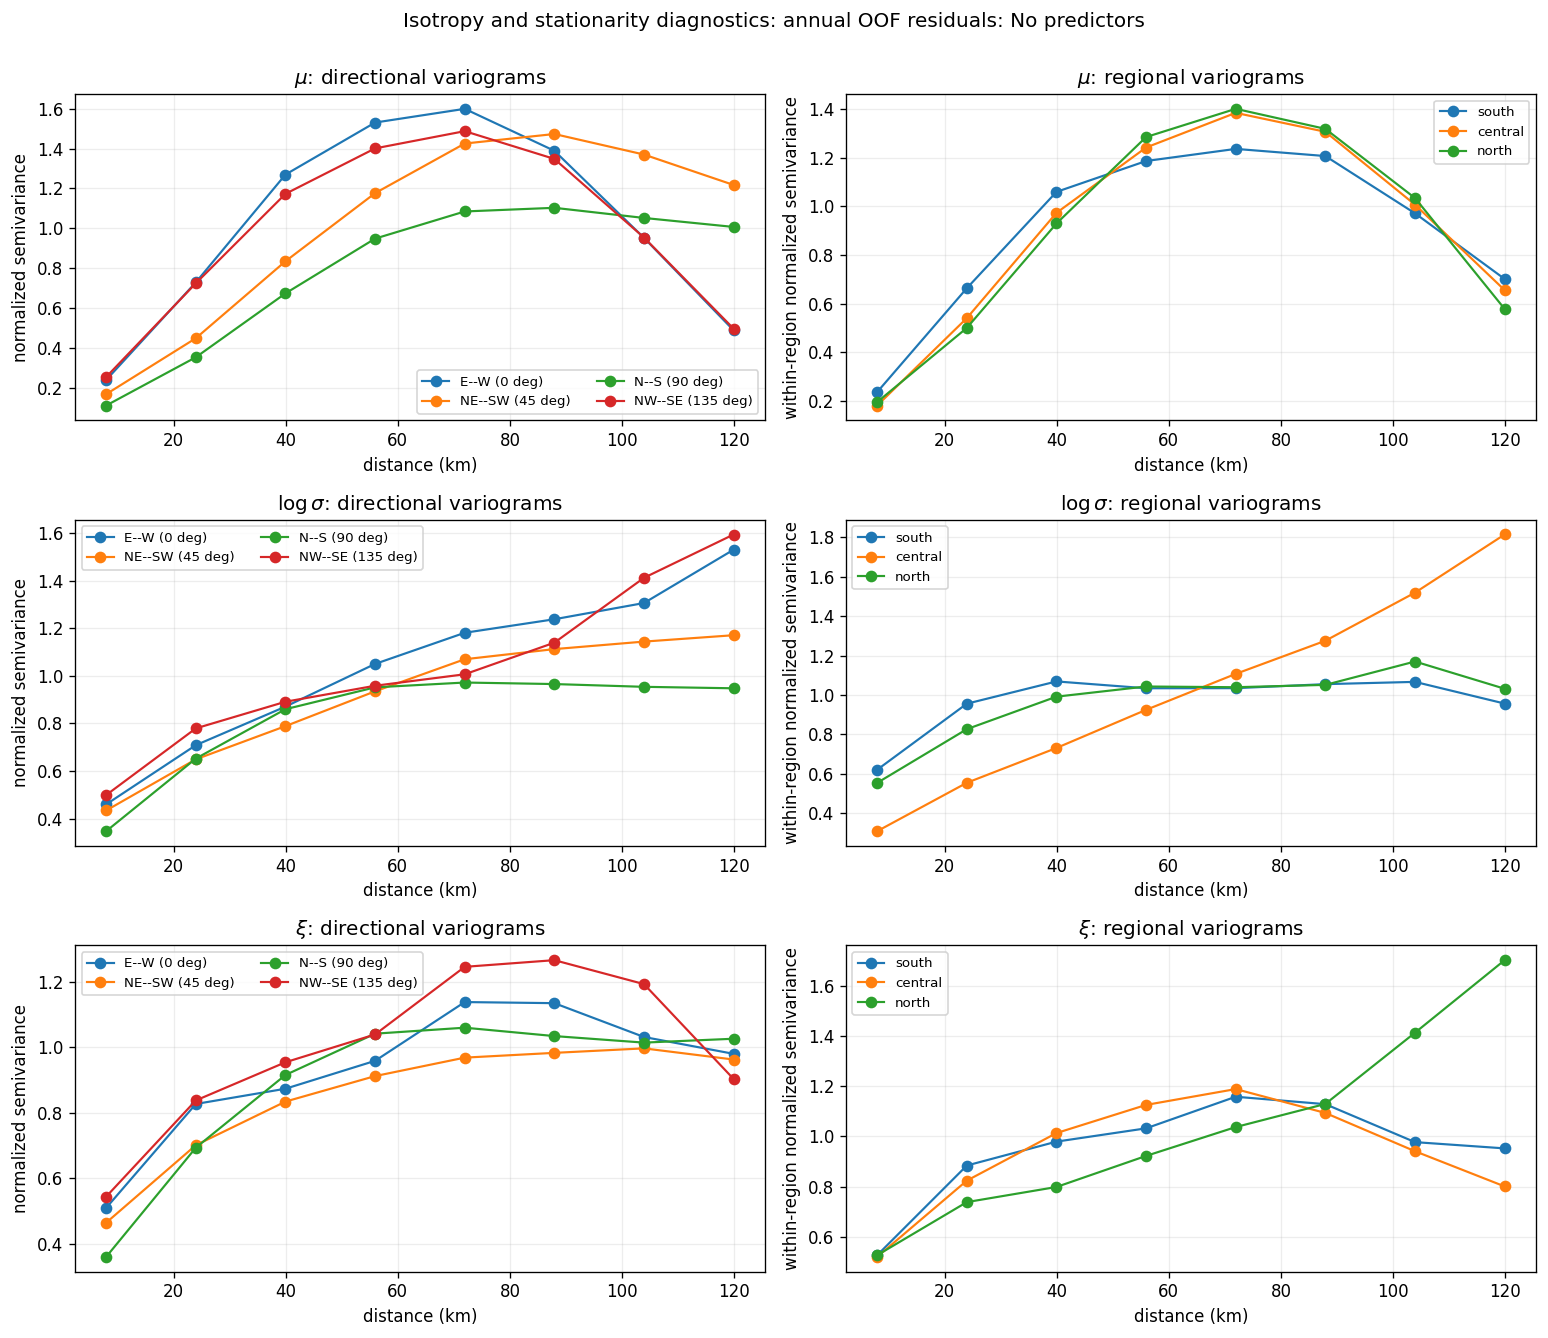

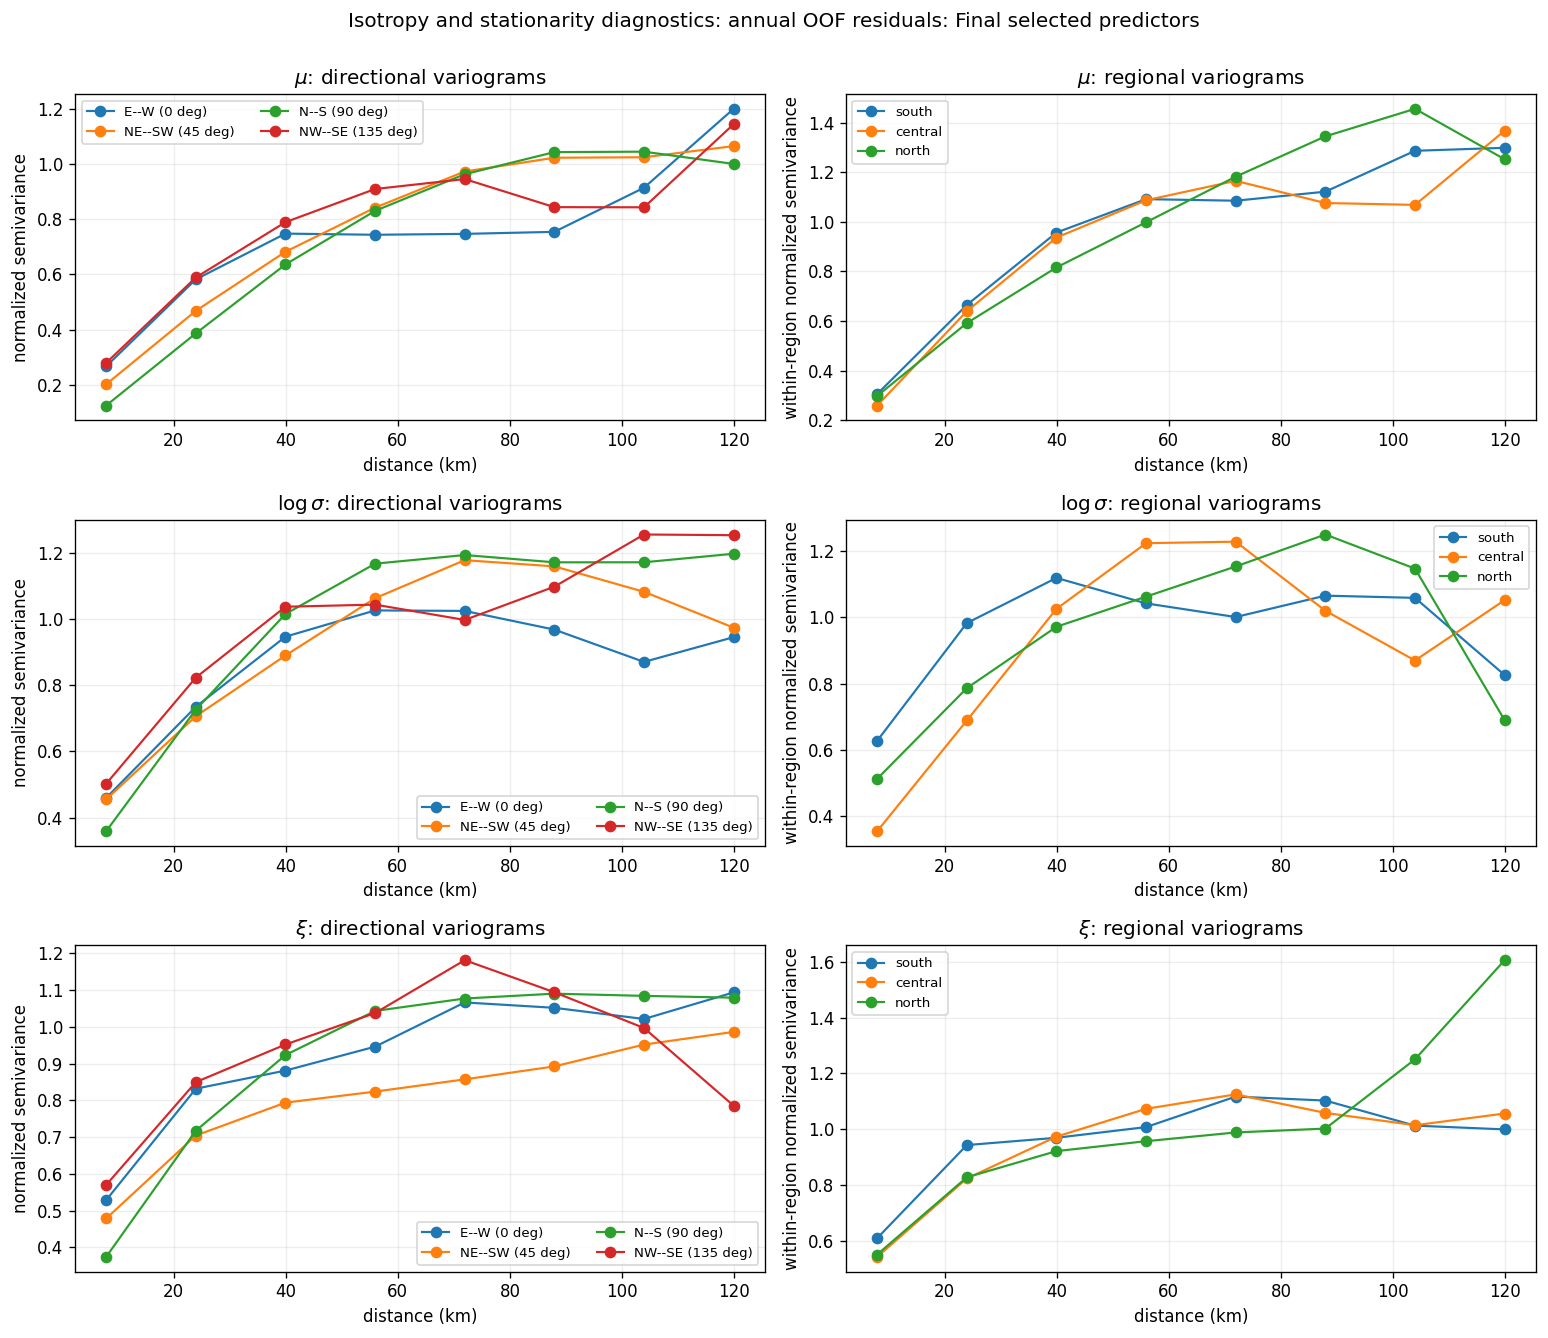

,stage,value_kind,target,n,directional_variogram_contrast,regional_mean_range_in_sd,regional_log_variance_ratio,regional_variogram_contrast
0,No predictors,annual OOF residuals: No predictors,mu,1385,0.4668,0.2607,0.4852,0.1175
1,No predictors,annual OOF residuals: No predictors,log_sigma,1385,0.1804,0.6014,0.5483,0.3251
2,No predictors,annual OOF residuals: No predictors,xi,1385,0.1641,0.6669,0.3235,0.1769
3,Final selected predictors,annual OOF residuals: Final selected predictors,mu,1385,0.2005,0.9603,0.7587,0.1060
4,Final selected predictors,annual OOF residuals: Final selected predictors,log_sigma,1385,0.1715,0.6635,0.4659,0.2509
5,Final selected predictors,annual OOF residuals: Final selected predictors,xi,1385,0.1987,0.7899,0.3546,0.1177


In [18]:
summary_parts = []
file_slugs = {
    STAGES[0]: 'no_predictors',
    STAGES[1]: 'final_selected_predictors',
}
for stage in STAGES:
    stage_long = comparison.loc[comparison['stage'].eq(stage)].copy()
    stage_residuals = prepare_selected_oof_residuals(
        stage_long, data[['station', 'x_km', 'y_km']]
    )
    slug = file_slugs[stage]
    stage_summary, stage_figure = plot_isotropy_stationarity_diagnostics(
        stage_residuals,
        value_columns={
            'mu': 'mu_residual',
            'log_sigma': 'log_sigma_residual',
            'xi': 'xi_residual',
        },
        value_kind=f'annual OOF residuals: {stage}',
        output_figure_path=(
            FIGURE_DIR / f'annual_{slug}_oof_isotropy_stationarity.png'
        ),
        output_table_path=(
            TABLE_DIR / f'annual_{slug}_oof_isotropy_stationarity.csv'
        ),
    )
    stage_summary.insert(0, 'stage', stage)
    summary_parts.append(stage_summary)
    plt.show()

spatial_summary = pd.concat(summary_parts, ignore_index=True)
spatial_summary.to_csv(
    TABLE_DIR / 'annual_no_predictors_vs_final_spatial_diagnostics.csv',
    index=False, encoding='utf-8-sig',
)
display(spatial_summary.round(4))

## 4. 兩模型診斷指標直接比較

四項 contrast 都以接近 0 為較理想；不使用單一任意門檻宣稱模型已完全 isotropic 或 stationary。

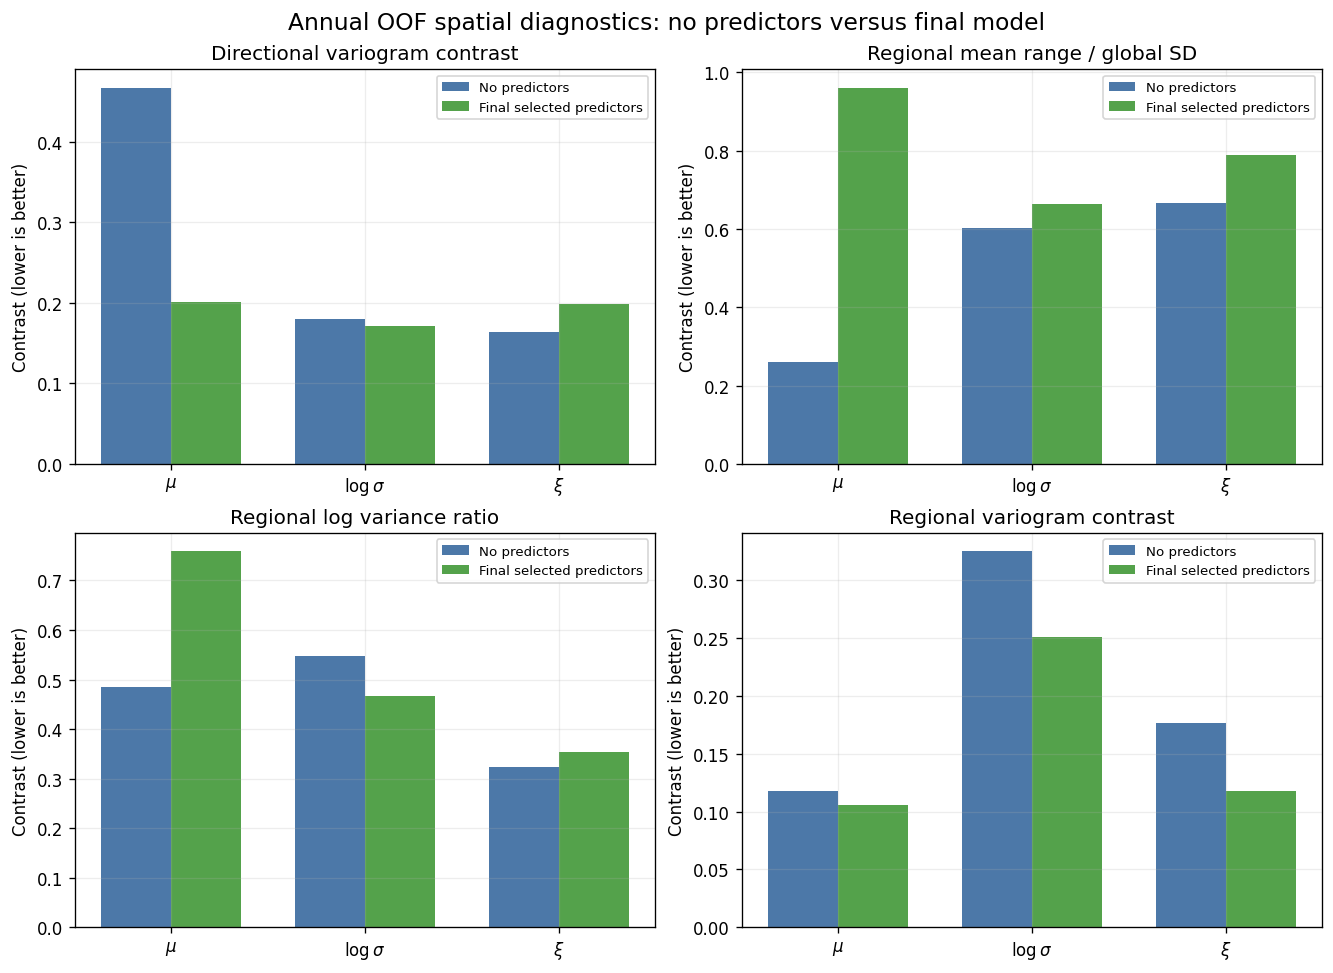

C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\results\figures\annual_no_predictors_vs_final_spatial_diagnostics.png


In [19]:
diagnostics = [
    ('directional_variogram_contrast', 'Directional variogram contrast'),
    ('regional_mean_range_in_sd', 'Regional mean range / global SD'),
    ('regional_log_variance_ratio', 'Regional log variance ratio'),
    ('regional_variogram_contrast', 'Regional variogram contrast'),
]
colors = {STAGES[0]: '#4C78A8', STAGES[1]: '#54A24B'}
labels = {'mu': r'$\mu$', 'log_sigma': r'$\log\sigma$', 'xi': r'$\xi$'}
x = np.arange(len(TARGETS))
width = 0.36
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, (column, title) in zip(axes.flat, diagnostics):
    for offset, stage in zip((-width / 2, width / 2), STAGES):
        values = (
            spatial_summary.loc[spatial_summary['stage'].eq(stage)]
            .set_index('target').reindex(TARGETS)[column]
            .to_numpy(float)
        )
        ax.bar(x + offset, values, width, label=stage, color=colors[stage])
    ax.set_title(title)
    ax.set_xticks(x, [labels[target] for target in TARGETS])
    ax.set_ylabel('Contrast (lower is better)')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
fig.suptitle(
    'Annual OOF spatial diagnostics: no predictors versus final model',
    fontsize=14,
)
summary_figure_path = (
    FIGURE_DIR / 'annual_no_predictors_vs_final_spatial_diagnostics.png'
)
fig.savefig(summary_figure_path, bbox_inches='tight', facecolor='white')
plt.show()
print(summary_figure_path)

## 判讀

- Directional contrast 下降：final predictors 減少方向性；若仍高，考慮 anisotropic covariance。
- Regional mean contrast 仍高：可能遺漏區域性的 mean predictor。
- Regional variance／variogram contrast 仍高：考慮 nonstationary variance、range 或 nugget，不一定是漏 predictor。
- 新增 predictor 或 covariance 後，仍須用相同 buffered Spatial CV 驗證 OOF RMSE。